In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

In [8]:
model = "student"
dataset = "amazon"
two = True
layers = "2_2_2"

with open(f"models/{model}_{dataset}_{two}_{layers}.json") as f:
    js = json.load(f)

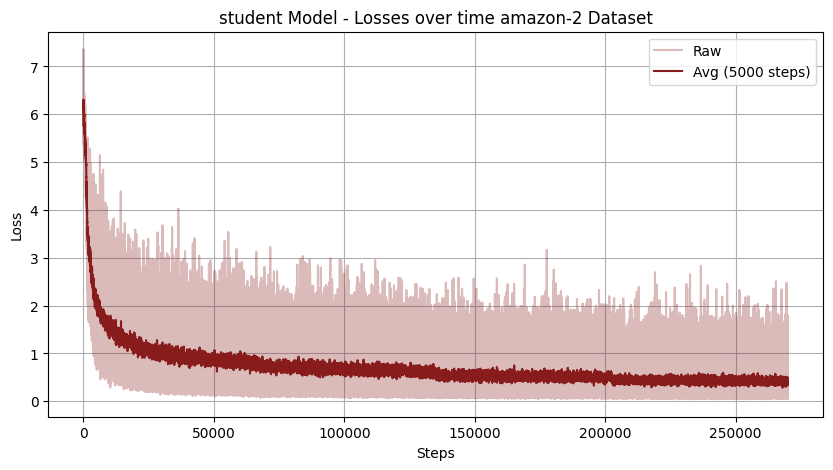

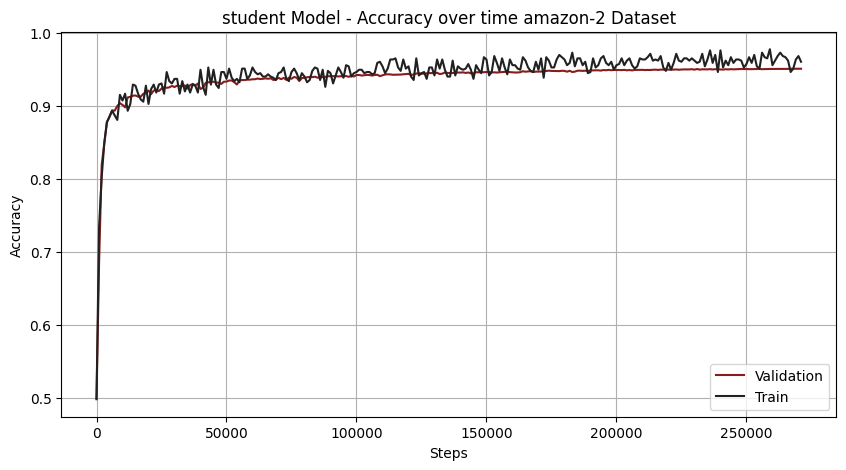

In [9]:
def running_avg(data, window=50):
    return [np.mean(data[max(0, i-window+1):i+1]) for i in range(len(data))]

steps = [i for i in range(len(js["losses"]))]
smoothed = running_avg(js["losses"])

plt.figure(figsize=(10, 5))
plt.title(f"{model} Model - Losses over time {dataset}-{2 if two else 5} Dataset")
plt.plot(steps, js["losses"], color="#881c1c", alpha=0.3, label="Raw")
plt.plot(steps, smoothed, color="#881c1c", label="Avg (5000 steps)")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(f"figures/loss_{model}_{dataset}_{two}_{layers}.png")
plt.show()

steps = [i * 1000 for i in range(len(js["validation_accs"]))]
plt.figure(figsize=(10, 5))
plt.title(f"{model} Model - Accuracy over time {dataset}-{2 if two else 5} Dataset")
plt.plot(steps, js["validation_accs"], color="#881c1c", label="Validation")
plt.plot(steps, js["train_accs"], color="#212121", label="Train")
plt.grid()
plt.xlabel("Steps")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(f"figures/accuracy_{model}_{dataset}_{two}_{layers}.png")
plt.show()